Application to a five-dimensional particle physics phase space integral - sampling from a highly complex distribution; estimating the decay width of the top quark, the heaviest elementary particle.

Preliminaries

In [1]:
import importlib
import coupling_layers as cl
import element
import numpy as np

importlib.reload(cl)
importlib.reload(element)

from element import get_matrix_element
import vegas
from test_vegas import vegas_decay_width_estimator

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
import pandas as pd
import gc

import matplotlib.font_manager as fm
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
})

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [4]:
m_t = 173       #top quark mass in GeV

Checks - dimensions, kinematic constraints, Madgraph matrix elements working correctly

In [5]:
N = 10
X = torch.rand(N, 5, device=device, dtype=torch.float64)
(P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
print(P.shape, P1.shape, P2.shape, P3.shape, jac_map.shape)


torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10])


In [6]:
element.check_conservation(P1, P2, P3, m_t, tol=1e-10)

Max |E1+E2+E3 - m_t|: 0.0
Max |p1+p2+p3|: 0.0
Conservation checks passed


In [7]:
me_values = element.batch_element_eval(P, P1, P2, P3, device=device, dtype=np.float64) * jac_map
print(me_values)

tensor([5.2719e+05, 2.1996e+04, 1.8595e+03, 2.4922e+06, 3.1668e+05, 1.0656e+05,
        6.4013e+05, 8.1622e+04, 1.0108e+05, 6.5452e+05], device='cuda:0',
       dtype=torch.float64)


In [ ]:
# 5 coupling layers transforming one variable at a time
# These will be used for the flows which check the Jacobian map below and train on the domain

A_dims = [torch.tensor([1, 2, 3, 4]), 
          torch.tensor([0, 2, 3, 4]),
          torch.tensor([0, 1, 3, 4]),
          torch.tensor([0, 1, 2, 4]),
          torch.tensor([0, 1, 2, 3])]
                

B_dims = [torch.tensor([0]),
          torch.tensor([1]),
          torch.tensor([2]),
          torch.tensor([3]),
          torch.tensor([4])]
                

In [ ]:
#check integral - integrate 'one'.  Result should be one!
N_test = 1_000_000
batch_size = 100_000

test_flow = cl.normalising_flow(
    layer_type=cl.pwl_layer,
    A_dims=A_dims,
    B_dims=B_dims,
    K=64,
    hidden_size=16,
    min_bin_width=1e-3
)

device = next(test_flow.parameters()).device
dtype = torch.float64
test_flow = test_flow.to(device=device, dtype=dtype)
test_flow.eval()

sum_jac = torch.tensor(0.0, device=device, dtype=dtype)
sum_jac2 = torch.tensor(0.0, device=device, dtype=dtype)
n_done = 0

with torch.inference_mode():
    for start in range(0, N_test, batch_size):
        b = min(batch_size, N_test - start)

        Y_batch = torch.rand((b, 5), device=device, dtype=dtype)
        _, jacobian_batch = test_flow.inverse(Y_batch)

        sum_jac += jacobian_batch.sum()
        sum_jac2 += (jacobian_batch**2).sum()
        n_done += b

mean_jac = sum_jac / n_done
var_jac = sum_jac2 / n_done - mean_jac**2
var_jac = torch.clamp(var_jac, min=0.0)
std_jac = torch.sqrt(var_jac)
error = std_jac / torch.sqrt(torch.tensor(n_done, device=device, dtype=dtype))

print(mean_jac.item(), error.item())

0.9999018964279878 0.0005407332768696394


Train the normalising flow on the integrand using batches of random numbers on [0,1]^5 mapped onto 4-momenta with which to evaluate matrix elements.  Training uses the Adam optimiser.

In [12]:
final_loss, loss_values, smooth_loss_values, flow = cl.train_loop_decay(
    D=5,
    layer_type=cl.pwq_layer,
    A_dims=A_dims,
    B_dims=B_dims,
    K=64,
    hidden_size=66,
    N=10_000,
    epochs=3500,
    lr=3e-5,
    device=device,
    dtype=np.float64,
    ticker=False,
    max_grad_norm=30.0,
    lr_plateau_factor=0.5,
    lr_plateau_patience=200,
    early_stopping_patience=300,
    early_stopping_min_delta=2e-3,
    ma_window=75,
    lr_cooldown=150,
    max_lr_reductions=3,
    min_lr=3e-5 / 10,
)

Normalisation scale: 21207614.371346083


In [14]:
#check integral after - again, should be one
N_test = 1_000_000
batch_size = 100_000
flow = flow.to('cpu')
flow.eval()

sum_jac_after = 0.0
sum_jac2_after = 0.0
n_done_a = 0

with torch.inference_mode():
    for start in range(0, N_test, batch_size):
        b = min(batch_size, N_test - start)

        Y_batch = torch.rand(b, 5, dtype=torch.float64)
        X_batch, jac_after = flow.inverse(Y_batch)

        sum_jac_after += jac_after.sum()
        sum_jac2_after += (jac_after**2).sum()
        n_done_a += b

mean_jac_after = sum_jac_after / n_done_a
var_jac_after = sum_jac2_after / n_done_a - mean_jac_after**2
std_jac_after = torch.sqrt(var_jac_after)
error_after = std_jac_after / torch.sqrt(torch.tensor(n_done_a, dtype=mean_jac_after.dtype))

print(mean_jac_after.item(), error_after.item())


1.0003252034363994 0.004608283453269934


Plot loss behaviour

In [15]:
def moving_average(loss_values, window_size=50):
    if loss_values.dim() != 1:
        raise ValueError("loss_values must be 1D")
    if window_size < 1:
        raise ValueError("window_size must be at least 1")

    mov_avg = torch.empty(len(loss_values) - window_size + 1, dtype=loss_values.dtype, device=loss_values.device)
    for i in range(window_size - 1, len(loss_values)):
        mov_avg[i - window_size + 1] = loss_values[i - window_size + 1:i + 1].mean()

    return mov_avg, window_size


mov_avg, window_size = moving_average(loss_values.cpu(), window_size=50)

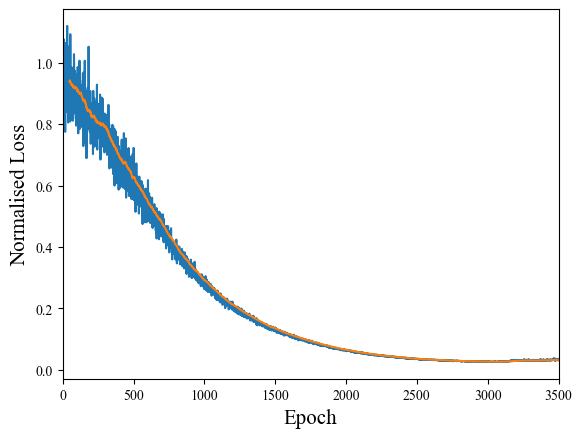

In [16]:
fig, ax = plt.subplots()

epochs_plot = torch.arange(len(loss_values))
epochs_avg = epochs_plot[window_size - 1:]
ax.plot(epochs_plot, loss_values.cpu().numpy(), label='Raw loss')

ax.plot(epochs_avg, mov_avg, label='Moving average')

ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Normalised Loss', fontsize=15)
ax.set_xlim(0, len(loss_values))

plt.show()

The slight rebound in loss at the end of the above plot could indicate overtraining; the early stopping criteria must be tuned

In [ ]:
#generate data for different numbers of bins for the transformations

K_s = [4, 8, 16, 32, 64, 128, 256]

results = {}
flows = {}

for K in K_s:
    final_loss, losses, smooth_losses, flow = cl.train_loop_decay(
        D=5,
        layer_type=cl.pwq_layer,
        A_dims=A_dims,
        B_dims=B_dims,
        K=K,
        hidden_size=16,
        N=5000,
        epochs=6000,
        lr=3e-5,
        device=device,
        dtype=np.float64,
        ticker=False,
        max_grad_norm=30.0,
        lr_plateau_factor=0.5,
        lr_plateau_patience=200,
        early_stopping_patience=300,
        early_stopping_min_delta=2e-3,
        ma_window=75,
        lr_cooldown=150,
        max_lr_reductions=3,
        min_lr=3e-5 / 10,
    )

    results[K] = {
        "final_loss": final_loss.detach().cpu(),
        "losses": losses.detach().cpu(),
        "smooth_losses": smooth_losses.detach().cpu(),
    }

    flows[K] = flow.eval()

Normalisation scale: 19933169.991232548
Normalisation scale: 21658697.093541715
Normalisation scale: 20028196.853774883
Normalisation scale: 20185137.0189557
Normalisation scale: 19470857.30956486
Normalisation scale: 20069293.819630247
Normalisation scale: 20895019.816119343


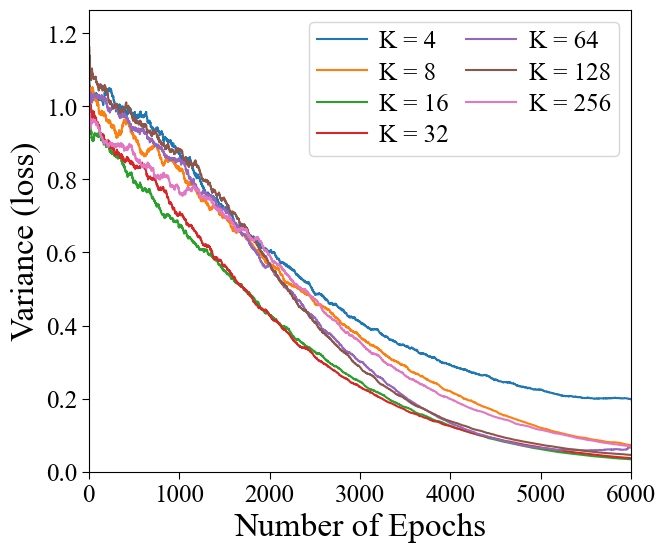

In [ ]:
# plotting for early stopping enabled

fig, ax = plt.subplots(figsize=(7, 6))

colors = plt.cm.tab10.colors  # already colorblind-safe

for i, (K, run_data) in enumerate(results.items()):
    losses = run_data["losses"]
    smooth_losses = run_data["smooth_losses"]

    epochs_plot = torch.arange(len(smooth_losses))
    ax.plot(
        epochs_plot,
        smooth_losses.numpy(),
        label=f"K = {K}",
        color=colors[i % len(colors)],
    )

ax.set_xlabel("Number of Epochs", fontsize=24)
ax.set_ylabel("Variance (loss)", fontsize=24)

ax.tick_params(axis="both", which="major", direction="out", length=5, labelsize=18)

ax.set_xlim(0, 6000)
ax.set_ylim(bottom=0)

ax.legend(
    ncol=2,
    columnspacing=0.7,   # space between columns
    handletextpad=0.5,   # space between line and label
    labelspacing=0.3,    # vertical spacing between rows
    borderpad=0.3,       # padding inside legend box
    fontsize=18
)

plt.show()

Unlike the purely mathematical testing scenarios, there is less of a correlation between the number of bins in the piecewise transformations and the variance reduction ability of the coupling layers here.  These ideas are explored in the report

Estimate decay width; plot event weights

In [17]:
def flow_decay_width_estimator(flow, B_total, chunk_size):

    flow = flow.to('cpu')
    flow.eval()

    prefactor = 1 / ((2*torch.pi)**5 * 16 * m_t)

    sum_w = torch.tensor(0.0, dtype=torch.float64)
    sum_w2 = torch.tensor(0.0, dtype=torch.float64)
    n_total = 0

    with torch.inference_mode():
        # optional one-off diagnostic check
        Y_test = torch.rand((1000, 5), device='cpu', dtype=torch.float64)
        X_test, _ = flow.inverse(Y_test)
        (_, P1t, P2t, P3t), _ = element.hypercube_to_momenta(X_test, m_t)
        element.check_conservation(P1t, P2t, P3t, m_t, tol=1e-10)
        del Y_test, X_test, P1t, P2t, P3t

        events_all =[]
        weights_all = []

        for i in range(0, B_total, chunk_size):
            b = min(chunk_size, B_total - i)

            Y = torch.rand((b, 5), device='cpu', dtype=torch.float64)
            X, jac_dets = flow.inverse(Y)

            (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)

            me2_vals = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)

            weights = prefactor * me2_vals * jac_dets * jac_map
            events = torch.stack((P, P1, P2, P3), dim=1)        #shape (b, 4, 4)

            events_all.append(events.detach().clone())
            weights_all.append(weights.detach().clone())

            sum_w += weights.sum()
            sum_w2 += (weights * weights).sum()
            n_total += b

            del Y, X, jac_dets, P, P1, P2, P3, jac_map, me2_vals, events, weights

            if (i // chunk_size) % 10 == 0:
                gc.collect()

    mean = sum_w / n_total
    var = (sum_w2 / n_total) - mean**2
    stderr = torch.sqrt(var / n_total)

    events_all = torch.cat(events_all, dim=0)        #shape (N, 4, 4)
    weights_all = torch.cat(weights_all)             #shape (N,)

    return mean, stderr, events_all, weights_all

In [14]:
def uniform_decay_width_estimator(B_total, chunk_size):
    
    prefactor = 1 / ((2*torch.pi)**5 * 16 * m_t)

    sum_w = torch.tensor(0.0, dtype=torch.float64)
    sum_w2 = torch.tensor(0.0, dtype=torch.float64)
    n_total = 0

    # optional one-off diagnostic check
    X_test = torch.rand((1000, 5), device='cpu', dtype=torch.float64)
    (_, P1t, P2t, P3t), _ = element.hypercube_to_momenta(X_test, m_t)
    element.check_conservation(P1t, P2t, P3t, m_t, tol=1e-10)
    del X_test, P1t, P2t, P3t

    events_all = []
    weights_all = []

    for i in range(0, B_total, chunk_size):
        b = min(chunk_size, B_total - i)

        X = torch.rand((b, 5), device='cpu', dtype=torch.float64)

        (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)

        me2_vals = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)

        events = torch.stack((P, P1, P2, P3), dim=1)

        weights = prefactor * me2_vals * jac_map
        events_all.append(events.detach().clone())
        weights_all.append(weights.detach().clone())

        sum_w += weights.sum()
        sum_w2 += (weights * weights).sum()
        n_total += b

        del X, P, P1, P2, P3, jac_map, me2_vals, events, weights

        if (i // chunk_size) % 10 == 0:
            gc.collect()

    mean = sum_w / n_total
    var = (sum_w2 / n_total) - mean**2
    stderr = torch.sqrt(var / n_total)

    events_all = torch.cat(events_all, dim=0)
    weights_all = torch.cat(weights_all)

    return mean, stderr, events_all, weights_all

Flow-derived results

In [18]:
mean, stderr, events, weights = flow_decay_width_estimator(flow, B_total=1000000, chunk_size=100000)

print(f"Flow-derived decay width estimate = {mean} ± {stderr}")

Max |E1+E2+E3 - m_t|: 0.0
Max |p1+p2+p3|: 0.0
Conservation checks passed
Flow-derived decay width estimate = 0.16369527530759345 ± 0.00010154208250719125


(Un-optimised) uniform-derived results

In [33]:
mean_u, stderr_u, events_u, weights_u = uniform_decay_width_estimator(B_total=1000000, chunk_size=100000)
print(f"Uniform-derived decay width estimate = {mean_u} ± {stderr_u}")

Max |E1+E2+E3 - m_t|: 2.842170943040401e-14
Max |p1+p2+p3|: 0.0
Conservation checks passed
Uniform-derived decay width estimate = 0.16417622425492928 ± 0.0007430227060729565


VEGAS-derived results

In [ ]:
mean_vegas, stderr_vegas, events_vegas, weights_vegas, integ, result = vegas_decay_width_estimator(
    B_total=1_000_000,
    nitn_adapt=10,
    neval_adapt=8000,
    nitn_prod=10,
    neval_prod=10_000,
    nhcube_batch=1000
)

Max |E1+E2+E3 - m_t|: 2.842170943040401e-14
Max |p1+p2+p3|: 0.0
Conservation checks passed


In [9]:
print(f"Vegas-derived decay width estimate = {mean_vegas} ± {stderr_vegas}")

Vegas-derived decay width estimate = 0.16385132760216153 ± 0.0001396138207127333


The uncertainty on the NF estimate is several times lower than for the naive un-optimised estimate.  It is similar to that of VEGAS

In [15]:
import pandas as pd
import os

def save_decay_result_pandas(filename, row_dict):
    df_row = pd.DataFrame([row_dict])

    if os.path.exists(filename):
        df_row.to_csv(filename, mode="a", header=False, index=False)
    else:
        df_row.to_csv(filename, index=False)

Plot the distribution of event weights

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import LogLocator, NullFormatter, AutoMinorLocator


def plot_weight_distributions_inset(
    weight_dict,
    bins=150,
    logy=True,
    figsize=(7, 6),
    inset_xlim=(0.0, 2.5),
    inset_width="42%",
    inset_height="42%",
    inset_loc="upper right",
    inset_logy=None,
):
    fig, ax = plt.subplots(figsize=figsize)

    if inset_logy is None:
        inset_logy = logy

    # normalise all weights first
    normed = {}
    for label, weights in weight_dict.items():
        weights = np.asarray(weights, dtype=float)
        w_mean = np.mean(weights)
        normed[label] = weights / w_mean

    # shared bins across all datasets
    all_weights = np.concatenate(list(normed.values()))
    bin_edges = np.histogram_bin_edges(all_weights, bins=bins)

    # main plot
    for label, weights_norm in normed.items():
        counts, _ = np.histogram(weights_norm, bins=bin_edges, density=False)
        ax.step(bin_edges[:-1], counts, where="post", label=label, linewidth=1.5)

    ax.set_xlabel(r"$w/\langle w\rangle$", fontsize=24)
    ax.set_ylabel("Number of Events", fontsize=24)
    ax.set_xlim(0, 20)

    ax.tick_params(axis="both", which="major", direction="out", length=5, labelsize=18)
    ax.tick_params(axis="x", which="minor", direction="out", length=3)
    ax.minorticks_on()

    if logy:
        ax.set_yscale("log")

    # inset axis
    axins = inset_axes(
        ax,
        width=inset_width,
        height=inset_height,
        loc=inset_loc,
        borderpad=1.0,
    )

    inset_edges = np.histogram_bin_edges(
        all_weights[(all_weights >= inset_xlim[0]) & (all_weights <= inset_xlim[1] + 0.05)],
        bins=max(40, bins // 3)
    )

    if len(inset_edges) < 2:
        inset_edges = np.linspace(inset_xlim[0], inset_xlim[1], max(40, bins // 3) + 1)

    inset_positive = []

    for label, weights_norm in normed.items():
        counts_inset, _ = np.histogram(weights_norm, bins=inset_edges, density=False)
        axins.step(inset_edges[:-1], counts_inset, where="post", linewidth=1.2)
        inset_positive.extend(counts_inset[counts_inset > 0])

    axins.set_xlim(0, inset_xlim[1])

    #restore x minor ticks explicitly
    axins.xaxis.set_minor_locator(AutoMinorLocator())

    if inset_logy:
        axins.set_yscale("log")

    axins.set_ylim(100)

    #if len(inset_positive) > 0:
        #ymin = min(inset_positive)
        #ymax = max(inset_positive)
        #axins.set_ylim(ymin * 0.8, ymax * 1.2)

    axins.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
    axins.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
    axins.yaxis.set_minor_formatter(NullFormatter())

    axins.yaxis.set_ticks_position("left")

    axins.tick_params(axis="both", which="major", direction="out", length=5, labelsize=18)
    axins.tick_params(axis="both", which="minor", direction="out", length=3)

    axins.set_xlabel("")
    axins.set_ylabel("")

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_958/668868064.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


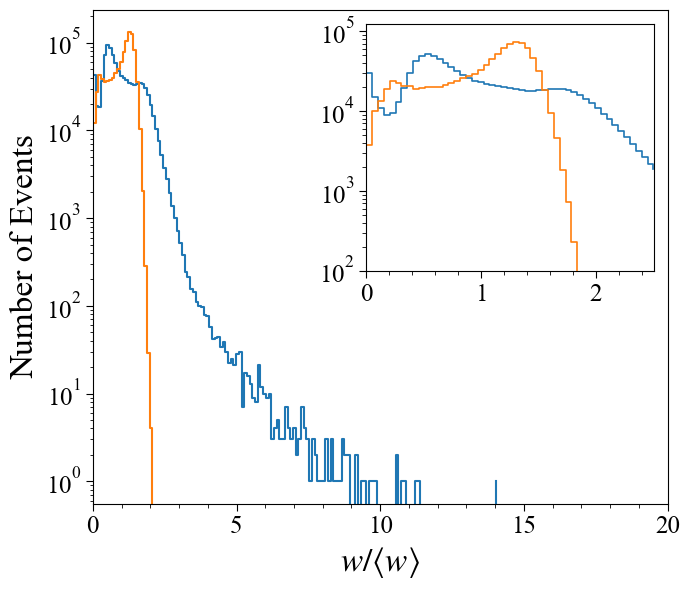

In [ ]:
plot_weight_distributions_inset(
    {"Flow": weights,       #blue
    "VEGAS": weights_vegas},    #orange
    bins=150,
    logy=True,
    inset_xlim=(0, 2.5),
    inset_width="50%",
    inset_height="50%",
)

Although the normalising flow method has nominally reduced the variance of the MC estimator, VEGAS has been superior in eliminating large event weights, as shown by the steep orange tail.  As the unweighting efficiency depends on the largest weight present, VEGAS will undoubtedly be superior in this regard too.  (These calculations were done elsewhere.)

Plot histogram of (p_e+ + p_ve)^2 for all methods; should see resonance around M_W^2 (illustrates kinematics)

In [17]:
def uniform_W_products_momenta_hist(B_total, chunk_size):

    '''Returns B_total values of (p_e+ + p_ve)^2'''

    
    with torch.inference_mode():
        # optional one-off diagnostic check
        #Y_test = torch.rand((1000, 5), device='cpu', dtype=torch.float64)
        #X_test, _ = flow.inverse(Y_test)
        #(_, P1t, P2t, P3t), _ = element.hypercube_to_momenta(X_test, m_t)
        #element.check_conservation(P1t, P2t, P3t, m_t, tol=1e-10)
        #del Y_test, X_test, P1t, P2t, P3t

        P23square = []
        me2_vals = []

        for i in range(0, B_total, chunk_size):
            b = min(chunk_size, B_total - i)

            X = torch.rand((b, 5), device='cpu', dtype=torch.float64)
            

            (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
            me2 = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)
            minkowski_prod = (
                        (P2[:,0] + P3[:,0])**2
                        - (P2[:,1] + P3[:,1])**2
                        - (P2[:,2] + P3[:,2])**2
                        - (P2[:,3] + P3[:,3])**2
                    )

            P23square.append(minkowski_prod)
            me2_vals.append(me2)

            del X, P, P1, P2, P3, jac_map

            if (i // chunk_size) % 10 == 0:
                gc.collect()

    P23square = torch.cat(P23square)
    me2_vals = torch.cat(me2_vals)
    #histogram of weights
    bins = 200

    counts, bin_edges = np.histogram(P23square, bins=bins, weights=me2_vals, density=True)  #get histogram(s)

    plt.figure(figsize=(6,5))                                         

    plt.step(bin_edges[:-1], counts, where='post', label='Flow')            #plot using step style bin edges
    plt.vlines((6458), ymin=0, ymax=1e-3, colors='r', linestyles="dashed")


    plt.xlabel("$(P_{e^{+}} + P_{ve})^2$ (GeV$^2$)")
    plt.ylabel("Normalised distribution")
    plt.yscale('log')
    plt.xlim(0)

    #plt.legend()

    plt.show()

In [ ]:
def combined_methods_momenta_hist(flow_events, flow_weights, vegas_events, vegas_weights, bins=200):
    '''
    Plot the weighted, normalised histogram of
    (p_2 + p_3)^2 for flow and VEGAS events.

    Expected shapes
    flow_events   : (B_flow, 4, 4)
    vegas_events  : (B_vegas, 4, 4)
    flow_weights  : (B_flow)
    vegas_weights : (B_vegas)
    '''

    def to_numpy(x):
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return np.asarray(x)

    # Convert once
    flow_events = to_numpy(flow_events)
    flow_weights = to_numpy(flow_weights).reshape(-1)
    vegas_events = to_numpy(vegas_events)
    vegas_weights = to_numpy(vegas_weights).reshape(-1)

    # Extract p2 and p3
    p2_flow = flow_events[:, 2, :]
    p3_flow = flow_events[:, 3, :]

    p2_vegas = vegas_events[:, 2, :]
    p3_vegas = vegas_events[:, 3, :]

    # Minkowski square: (p2 + p3)^2 = E^2 - px^2 - py^2 - pz^2
    s23_flow = (
        (p2_flow[:, 0] + p3_flow[:, 0])**2
        - (p2_flow[:, 1] + p3_flow[:, 1])**2
        - (p2_flow[:, 2] + p3_flow[:, 2])**2
        - (p2_flow[:, 3] + p3_flow[:, 3])**2
    )

    s23_vegas = (
        (p2_vegas[:, 0] + p3_vegas[:, 0])**2
        - (p2_vegas[:, 1] + p3_vegas[:, 1])**2
        - (p2_vegas[:, 2] + p3_vegas[:, 2])**2
        - (p2_vegas[:, 3] + p3_vegas[:, 3])**2
    )

    # Common bin edges for fair comparison
    all_s23 = np.concatenate((s23_flow, s23_vegas))
    bin_edges = np.histogram_bin_edges(all_s23, bins=bins)

    counts_flow, _ = np.histogram(
        s23_flow, bins=bin_edges, weights=flow_weights, density=True
    )
    counts_vegas, _ = np.histogram(
        s23_vegas, bins=bin_edges, weights=vegas_weights, density=True
    )

    fig, ax = plt.subplots(figsize=(7, 6))

    ax.step(bin_edges[:-1], counts_flow, where='post', label='Flow')
    ax.step(bin_edges[:-1], counts_vegas, where='post', label='VEGAS')
    ax.axvline(6458, ymin=0, ymax=1, color='black', linestyle='dashed')

    ax.set_xlabel(r"$(P_{e^{+}} + P_{\nu_e})^2$ (GeV$^2$)", fontsize=24)
    ax.set_ylabel("Normalised Distribution", fontsize=24)
    ax.tick_params(axis="both", which="major", direction="out", length=5, labelsize=18)
    plt.yscale('log')
    ax.set_xlim(0, 30000)
    #ax.legend(fontsize=18)
    plt.tight_layout()

    plt.show()


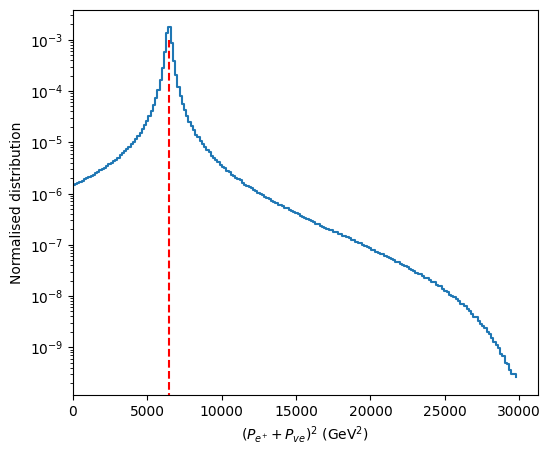

In [ ]:
uniform_W_products_momenta_hist(B_total=1_000_000, chunk_size=100_000)

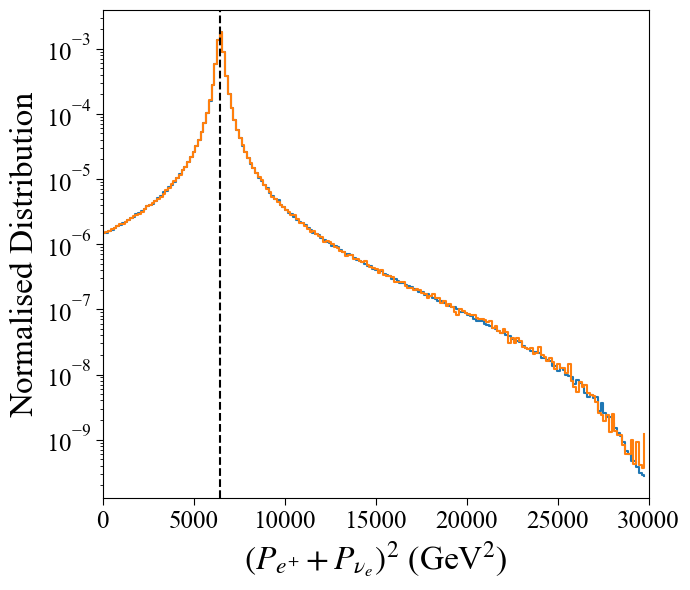

In [54]:
combined_methods_momenta_hist(events, weights, events_vegas, weights_vegas, bins=200)

As expected, all methods produce visible resonance behaviour around the squared top quark mass (6458 GeV^2 here), validating the kinematics situation.